# Inspect Gold Pageview Data

This notebook is a read-only quality gate for the Gold layer. It validates the aggregate table contracts, storage footprint, schema, grain uniqueness, hourly-to-daily reconciliation, top-page ranking rules, and readiness for research use.

The default run only reads compact Gold data and metadata. The Silver reconciliation section is intentionally gated because it scans the larger Silver layer.


## Operating Rules

- Treat Gold as serving/research aggregates, not a replacement for Silver row-level data.
- Validate table grain before doing analysis.
- Reconcile additive metrics across Gold tables before trusting trends.
- Keep expensive Silver scans explicit and reproducible.
- Do not write new datasets from this notebook.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path
from typing import Any

import pandas as pd
import pyarrow.dataset as ds
import pyarrow.parquet as pq

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

GOLD_DIR = ROOT / "data" / "processed" / "gold"
SILVER_DIR = ROOT / "data" / "processed" / "silver" / "pageviews"
BRONZE_MANIFEST_PATH = ROOT / "data" / "raw" / "pageviews_manifest.json"
SILVER_VALIDATION_REPORT_PATH = (
    ROOT / "data" / "processed" / "validation" / "silver_pageviews_validation.json"
)
GOLD_MANIFEST_PATH = GOLD_DIR / "gold_manifest.json"

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:.2f}".format)

RUN_SILVER_RECONCILIATION = False
TOP_N_SAMPLE_ROWS = 25
DATA_BUDGET_BYTES = 10_000_000_000

assert GOLD_DIR.exists(), f"Gold directory is missing: {GOLD_DIR}"
assert GOLD_MANIFEST_PATH.exists(), f"Gold manifest is missing: {GOLD_MANIFEST_PATH}"


def read_json(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text(encoding="utf-8-sig"))


def bytes_to_mb(value: int | float) -> float:
    return float(value) / 1024 / 1024


def bytes_to_gb(value: int | float) -> float:
    return float(value) / 1024 / 1024 / 1024


def folder_size(path: Path) -> int:
    if not path.exists():
        return 0
    return sum(file.stat().st_size for file in path.rglob("*") if file.is_file())


def parquet_files(path: Path) -> list[Path]:
    return sorted(path.rglob("*.parquet"))


def normalize_date_column(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    if "date" in result.columns:
        result["date"] = pd.to_datetime(result["date"]).dt.date.astype(str)
    if "hour" in result.columns:
        result["hour"] = result["hour"].astype("int16")
    return result


def display_checklist(checks: dict[str, bool]) -> pd.DataFrame:
    return pd.DataFrame(
        {"check": list(checks.keys()), "passed": list(checks.values())}
    ).assign(status=lambda frame: frame["passed"].map({True: "PASS", False: "FAIL"}))


## Gold Manifest Contract


In [2]:
gold_manifest = read_json(GOLD_MANIFEST_PATH)
silver_validation = (
    read_json(SILVER_VALIDATION_REPORT_PATH)
    if SILVER_VALIDATION_REPORT_PATH.exists()
    else None
)
bronze_manifest = read_json(BRONZE_MANIFEST_PATH) if BRONZE_MANIFEST_PATH.exists() else None

table_specs = gold_manifest["tables"]
table_paths = {
    table_name: GOLD_DIR / table_spec["path"]
    for table_name, table_spec in table_specs.items()
}

manifest_summary = pd.DataFrame(
    [
        {"field": "manifest_version", "value": gold_manifest.get("manifest_version")},
        {"field": "generated_at_utc", "value": gold_manifest.get("generated_at_utc")},
        {"field": "source_layer", "value": gold_manifest.get("source_layer")},
        {"field": "source_dir", "value": gold_manifest.get("source_dir")},
        {"field": "gold_dir", "value": gold_manifest.get("gold_dir")},
        {"field": "top_n_pages", "value": gold_manifest.get("top_n_pages")},
    ]
)
manifest_summary


,field,value
0,manifest_version,1
1,generated_at_utc,2026-08-24T16:53:46Z
2,source_layer,silver
3,source_dir,data\processed\silver\pageviews
4,gold_dir,data\processed\gold
5,top_n_pages,100


In [3]:
contract_rows = []
for table_name, table_spec in table_specs.items():
    table_path = table_paths[table_name]
    dataset = ds.dataset(table_path, format="parquet", partitioning="hive")
    actual_rows = dataset.count_rows()
    contract_rows.append(
        {
            "table": table_name,
            "grain": table_spec["grain"],
            "path": str(table_path.relative_to(ROOT)),
            "manifest_rows": int(table_spec["rows"]),
            "actual_rows": int(actual_rows),
            "row_count_matches_manifest": int(table_spec["rows"]) == int(actual_rows),
        }
    )

contract_df = pd.DataFrame(contract_rows)
contract_df


,table,grain,path,manifest_rows,actual_rows,row_count_matches_manifest
0,hourly_project_access,"date, hour, project, access_mode",data\processed\gold\hourly_project_access,504,504,True
1,daily_project_access,"date, project, access_mode",data\processed\gold\daily_project_access,21,21,True
2,top_pages_hourly,"date, hour, project, access_mode, rank_in_hour",data\processed\gold\top_pages_hourly,50400,50400,True


## Storage Footprint


In [4]:
inventory_rows = []
for table_name, table_path in table_paths.items():
    for file_path in parquet_files(table_path):
        metadata = pq.ParquetFile(file_path).metadata
        inventory_rows.append(
            {
                "table": table_name,
                "file": str(file_path.relative_to(ROOT)),
                "rows": metadata.num_rows,
                "row_groups": metadata.num_row_groups,
                "size_mb": bytes_to_mb(file_path.stat().st_size),
            }
        )

file_inventory_df = pd.DataFrame(inventory_rows)
file_inventory_df


,table,file,rows,row_groups,size_mb
0,hourly_project_access,data\processed\gold\hourly_project_access\date...,168,3,0.01
1,hourly_project_access,data\processed\gold\hourly_project_access\date...,168,3,0.01
2,hourly_project_access,data\processed\gold\hourly_project_access\date...,168,4,0.01
3,daily_project_access,data\processed\gold\daily_project_access\date=...,7,2,0.00
4,daily_project_access,data\processed\gold\daily_project_access\date=...,7,2,0.00
5,daily_project_access,data\processed\gold\daily_project_access\date=...,7,2,0.00
6,top_pages_hourly,data\processed\gold\top_pages_hourly\date=2026...,16800,5,0.39
7,top_pages_hourly,data\processed\gold\top_pages_hourly\date=2026...,16800,5,0.38
8,top_pages_hourly,data\processed\gold\top_pages_hourly\date=2026...,16800,4,0.36


In [5]:
storage_summary = (
    file_inventory_df.groupby("table", as_index=False)
    .agg(
        files=("file", "count"),
        parquet_rows=("rows", "sum"),
        row_groups=("row_groups", "sum"),
        size_mb=("size_mb", "sum"),
        avg_file_mb=("size_mb", "mean"),
        max_file_mb=("size_mb", "max"),
    )
    .sort_values("size_mb", ascending=False)
)

data_total_bytes = folder_size(ROOT / "data")
gold_total_bytes = folder_size(GOLD_DIR)

budget_summary = pd.DataFrame(
    [
        {
            "scope": "gold",
            "size_gb": bytes_to_gb(gold_total_bytes),
            "share_of_10gb": gold_total_bytes / DATA_BUDGET_BYTES,
        },
        {
            "scope": "data",
            "size_gb": bytes_to_gb(data_total_bytes),
            "share_of_10gb": data_total_bytes / DATA_BUDGET_BYTES,
        },
    ]
)

display(storage_summary)
budget_summary


,table,files,parquet_rows,row_groups,size_mb,avg_file_mb,max_file_mb
2,top_pages_hourly,3,50400,14,1.12,0.37,0.39
1,hourly_project_access,3,504,10,0.03,0.01,0.01
0,daily_project_access,3,21,6,0.01,0.00,0.00


,scope,size_gb,share_of_10gb
0,gold,0.00,0.00
1,data,8.28,0.89


## Schema Validation


In [6]:
required_columns = {
    "hourly_project_access": {
        "date",
        "hour",
        "project",
        "access_mode",
        "page_rows",
        "total_views",
        "total_response_size",
        "max_page_views",
        "avg_page_views",
        "approx_distinct_pages",
    },
    "daily_project_access": {
        "date",
        "project",
        "access_mode",
        "page_rows",
        "total_views",
        "total_response_size",
        "max_page_views",
        "avg_page_views",
        "approx_distinct_pages",
        "observed_hours",
    },
    "top_pages_hourly": {
        "date",
        "hour",
        "project",
        "access_mode",
        "source_project",
        "normalized_title",
        "page_title",
        "view_count",
        "response_size",
        "rank_in_hour",
    },
}

schema_rows = []
schema_check_rows = []
for table_name, table_path in table_paths.items():
    schema = ds.dataset(table_path, format="parquet", partitioning="hive").schema
    columns = {field.name for field in schema}
    missing_columns = sorted(required_columns[table_name] - columns)
    extra_columns = sorted(columns - required_columns[table_name])
    schema_check_rows.append(
        {
            "table": table_name,
            "required_columns_present": not missing_columns,
            "missing_columns": missing_columns,
            "extra_columns": extra_columns,
        }
    )
    for field in schema:
        schema_rows.append({"table": table_name, "column": field.name, "type": str(field.type)})

schema_df = pd.DataFrame(schema_rows)
schema_check_df = pd.DataFrame(schema_check_rows)

display(schema_check_df)
schema_df


,table,required_columns_present,missing_columns,extra_columns
0,hourly_project_access,True,[],[]
1,daily_project_access,True,[],[]
2,top_pages_hourly,True,[],[]


,table,column,type
0,hourly_project_access,hour,int32
1,hourly_project_access,project,string
2,hourly_project_access,access_mode,string
3,hourly_project_access,page_rows,int64
4,hourly_project_access,total_views,int64
5,hourly_project_access,total_response_size,int64
6,hourly_project_access,max_page_views,int64
7,hourly_project_access,avg_page_views,double
8,hourly_project_access,approx_distinct_pages,int64
9,hourly_project_access,date,string


## Load Gold Tables


In [7]:
def load_gold_table(table_name: str) -> pd.DataFrame:
    dataset = ds.dataset(table_paths[table_name], format="parquet", partitioning="hive")
    return normalize_date_column(dataset.to_table().to_pandas())


hourly_df = load_gold_table("hourly_project_access")
daily_df = load_gold_table("daily_project_access")
top_pages_df = load_gold_table("top_pages_hourly")

for frame in (hourly_df, daily_df, top_pages_df):
    numeric_columns = frame.select_dtypes(include=["number"]).columns
    frame[numeric_columns] = frame[numeric_columns].apply(pd.to_numeric, errors="coerce")

table_shape_df = pd.DataFrame(
    [
        {"table": "hourly_project_access", "rows": len(hourly_df), "columns": hourly_df.shape[1]},
        {"table": "daily_project_access", "rows": len(daily_df), "columns": daily_df.shape[1]},
        {"table": "top_pages_hourly", "rows": len(top_pages_df), "columns": top_pages_df.shape[1]},
    ]
)
table_shape_df


,table,rows,columns
0,hourly_project_access,504,10
1,daily_project_access,21,10
2,top_pages_hourly,50400,10


## Grain Uniqueness


In [8]:
def duplicate_summary(df: pd.DataFrame, key_columns: list[str], table_name: str) -> dict[str, Any]:
    duplicate_mask = df.duplicated(key_columns, keep=False)
    return {
        "table": table_name,
        "grain": ", ".join(key_columns),
        "duplicate_rows": int(duplicate_mask.sum()),
        "duplicate_keys": int(df.loc[duplicate_mask, key_columns].drop_duplicates().shape[0]),
        "passed": not bool(duplicate_mask.any()),
    }


hourly_key = ["date", "hour", "project", "access_mode"]
daily_key = ["date", "project", "access_mode"]
top_pages_key = ["date", "hour", "project", "access_mode", "rank_in_hour"]

grain_summary_df = pd.DataFrame(
    [
        duplicate_summary(hourly_df, hourly_key, "hourly_project_access"),
        duplicate_summary(daily_df, daily_key, "daily_project_access"),
        duplicate_summary(top_pages_df, top_pages_key, "top_pages_hourly"),
    ]
)
grain_summary_df


,table,grain,duplicate_rows,duplicate_keys,passed
0,hourly_project_access,"date, hour, project, access_mode",0,0,True
1,daily_project_access,"date, project, access_mode",0,0,True
2,top_pages_hourly,"date, hour, project, access_mode, rank_in_hour",0,0,True


In [9]:
# Show duplicate examples only if a grain check fails.
duplicate_examples = {
    "hourly_project_access": hourly_df.loc[
        hourly_df.duplicated(hourly_key, keep=False), hourly_key
    ].head(20),
    "daily_project_access": daily_df.loc[
        daily_df.duplicated(daily_key, keep=False), daily_key
    ].head(20),
    "top_pages_hourly": top_pages_df.loc[
        top_pages_df.duplicated(top_pages_key, keep=False), top_pages_key
    ].head(20),
}

for table_name, duplicate_df in duplicate_examples.items():
    if not duplicate_df.empty:
        display(table_name, duplicate_df)


## Coverage and Null Checks


In [10]:
hourly_pairs = hourly_df[["project", "access_mode"]].drop_duplicates().sort_values(
    ["project", "access_mode"]
)
hourly_hours = hourly_df[["date", "hour"]].drop_duplicates().sort_values(["date", "hour"])

top_n_pages = int(gold_manifest.get("top_n_pages", 100))
expected_hourly_rows = len(hourly_pairs) * len(hourly_hours)
expected_daily_rows = len(hourly_pairs) * hourly_df["date"].nunique()
expected_top_rows_if_full = expected_hourly_rows * top_n_pages

coverage_df = pd.DataFrame(
    [
        {"metric": "project/access pairs", "value": len(hourly_pairs)},
        {"metric": "distinct date/hour windows", "value": len(hourly_hours)},
        {"metric": "hourly rows", "value": len(hourly_df)},
        {"metric": "expected hourly rows from observed coverage", "value": expected_hourly_rows},
        {"metric": "daily rows", "value": len(daily_df)},
        {"metric": "expected daily rows from observed coverage", "value": expected_daily_rows},
        {"metric": "top page rows", "value": len(top_pages_df)},
        {"metric": "expected top rows if every group has top_n pages", "value": expected_top_rows_if_full},
    ]
)

null_check_df = pd.DataFrame(
    [
        {"table": "hourly_project_access", "null_cells": int(hourly_df.isna().sum().sum())},
        {"table": "daily_project_access", "null_cells": int(daily_df.isna().sum().sum())},
        {"table": "top_pages_hourly", "null_cells": int(top_pages_df.isna().sum().sum())},
    ]
)

display(hourly_pairs.reset_index(drop=True))
display(coverage_df)
null_check_df


,project,access_mode
0,commons,desktop
1,commons,mobile
2,en,desktop
3,en,mobile
4,vi,desktop
5,vi,mobile
6,wikidata,desktop


,metric,value
0,project/access pairs,7
1,distinct date/hour windows,72
2,hourly rows,504
3,expected hourly rows from observed coverage,504
4,daily rows,21
5,expected daily rows from observed coverage,21
6,top page rows,50400
7,expected top rows if every group has top_n pages,50400


,table,null_cells
0,hourly_project_access,0
1,daily_project_access,0
2,top_pages_hourly,0


## Metric Domain Checks


In [11]:
metric_checks = {
    "hourly page_rows positive": bool((hourly_df["page_rows"] > 0).all()),
    "hourly total_views non-negative": bool((hourly_df["total_views"] >= 0).all()),
    "hourly total_response_size non-negative": bool(
        (hourly_df["total_response_size"] >= 0).all()
    ),
    "daily page_rows positive": bool((daily_df["page_rows"] > 0).all()),
    "daily observed_hours between 1 and 24": bool(daily_df["observed_hours"].between(1, 24).all()),
    "top page ranks positive": bool((top_pages_df["rank_in_hour"] >= 1).all()),
    "top page view_count non-negative": bool((top_pages_df["view_count"] >= 0).all()),
    "top page response_size non-negative": bool((top_pages_df["response_size"] >= 0).all()),
    "top page titles populated": bool(
        top_pages_df["normalized_title"].notna().all() and top_pages_df["page_title"].notna().all()
    ),
}
metric_check_df = display_checklist(metric_checks)
metric_check_df


,check,passed,status
0,hourly page_rows positive,True,PASS
1,hourly total_views non-negative,True,PASS
2,hourly total_response_size non-negative,True,PASS
3,daily page_rows positive,True,PASS
4,daily observed_hours between 1 and 24,True,PASS
5,top page ranks positive,True,PASS
6,top page view_count non-negative,True,PASS
7,top page response_size non-negative,True,PASS
8,top page titles populated,True,PASS


## Hourly-to-Daily Reconciliation


In [12]:
hourly_to_daily = (
    hourly_df.groupby(daily_key, as_index=False)
    .agg(
        page_rows_from_hourly=("page_rows", "sum"),
        total_views_from_hourly=("total_views", "sum"),
        total_response_size_from_hourly=("total_response_size", "sum"),
        max_page_views_from_hourly=("max_page_views", "max"),
        observed_hours_from_hourly=("hour", "nunique"),
    )
)

daily_compare = daily_df.merge(hourly_to_daily, on=daily_key, how="outer", indicator=True)
for metric in ["page_rows", "total_views", "total_response_size", "max_page_views", "observed_hours"]:
    daily_compare[f"{metric}_delta"] = daily_compare[metric] - daily_compare[f"{metric}_from_hourly"]

delta_columns = [column for column in daily_compare.columns if column.endswith("_delta")]
reconciliation_failures = daily_compare.loc[
    (daily_compare["_merge"] != "both") | daily_compare[delta_columns].ne(0).any(axis=1)
]

reconciliation_summary = pd.DataFrame(
    [
        {"metric": "compared_daily_keys", "value": len(daily_compare)},
        {"metric": "failed_daily_keys", "value": len(reconciliation_failures)},
        {"metric": "max_abs_page_rows_delta", "value": daily_compare["page_rows_delta"].abs().max()},
        {"metric": "max_abs_total_views_delta", "value": daily_compare["total_views_delta"].abs().max()},
        {
            "metric": "max_abs_total_response_size_delta",
            "value": daily_compare["total_response_size_delta"].abs().max(),
        },
    ]
)

display(reconciliation_summary)
reconciliation_failures.head(25)


,metric,value
0,compared_daily_keys,21
1,failed_daily_keys,0
2,max_abs_page_rows_delta,0
3,max_abs_total_views_delta,0
4,max_abs_total_response_size_delta,0


,project,access_mode,page_rows,total_views,total_response_size,max_page_views,avg_page_views,approx_distinct_pages,observed_hours,date,page_rows_from_hourly,total_views_from_hourly,total_response_size_from_hourly,max_page_views_from_hourly,observed_hours_from_hourly,_merge,page_rows_delta,total_views_delta,total_response_size_delta,max_page_views_delta,observed_hours_delta


## Top Pages Ranking Checks


In [13]:
top_group_key = ["date", "hour", "project", "access_mode"]
rank_summary_df = (
    top_pages_df.groupby(top_group_key, as_index=False)
    .agg(
        rows=("rank_in_hour", "count"),
        min_rank=("rank_in_hour", "min"),
        max_rank=("rank_in_hour", "max"),
        unique_ranks=("rank_in_hour", "nunique"),
        max_view_count=("view_count", "max"),
        min_view_count=("view_count", "min"),
    )
)

invalid_rank_groups = rank_summary_df.loc[
    (rank_summary_df["min_rank"] != 1)
    | (rank_summary_df["max_rank"] > top_n_pages)
    | (rank_summary_df["rows"] != rank_summary_df["unique_ranks"])
]

ordered_top_pages = top_pages_df.sort_values(top_group_key + ["rank_in_hour"]).copy()
ordered_top_pages["previous_view_count"] = ordered_top_pages.groupby(top_group_key)["view_count"].shift(1)
rank_order_violations = ordered_top_pages.loc[
    ordered_top_pages["previous_view_count"].notna()
    & (ordered_top_pages["view_count"] > ordered_top_pages["previous_view_count"])
]

top_rank_checks = {
    "one rank-1 page per populated group": bool((rank_summary_df["min_rank"] == 1).all()),
    "no duplicate ranks within group": bool((rank_summary_df["rows"] == rank_summary_df["unique_ranks"]).all()),
    "rank cap respected": bool((rank_summary_df["max_rank"] <= top_n_pages).all()),
    "view_count non-increasing by rank": rank_order_violations.empty,
}

display(display_checklist(top_rank_checks))
display(rank_summary_df.describe(include="all"))
display(invalid_rank_groups.head(25))
rank_order_violations.head(25)


,check,passed,status
0,one rank-1 page per populated group,True,PASS
1,no duplicate ranks within group,True,PASS
2,rank cap respected,True,PASS
3,view_count non-increasing by rank,True,PASS


,date,hour,project,access_mode,rows,min_rank,max_rank,unique_ranks,max_view_count,min_view_count
count,504,504.00,504,504,504.00,504.00,504.00,504.00,504.00,504.00
unique,3,NaN,4,2,NaN,NaN,NaN,NaN,NaN,NaN
top,2026-01-01,NaN,commons,desktop,NaN,NaN,NaN,NaN,NaN,NaN
freq,168,NaN,144,288,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,11.50,NaN,NaN,100.00,1.00,100.00,100.00,41881.11,344.29
std,NaN,6.93,NaN,NaN,0.00,0.00,0.00,0.00,68451.20,689.41
min,NaN,0.00,NaN,NaN,100.00,1.00,100.00,100.00,86.00,2.00
25%,NaN,5.75,NaN,NaN,100.00,1.00,100.00,100.00,796.00,8.00
50%,NaN,11.50,NaN,NaN,100.00,1.00,100.00,100.00,1574.50,22.00
75%,NaN,17.25,NaN,NaN,100.00,1.00,100.00,100.00,85910.50,333.75


,date,hour,project,access_mode,rows,min_rank,max_rank,unique_ranks,max_view_count,min_view_count


,hour,project,access_mode,source_project,normalized_title,page_title,view_count,response_size,rank_in_hour,date,previous_view_count


## Top Page EDA


In [14]:
project_hourly_summary = (
    hourly_df.groupby(["project", "access_mode"], as_index=False)
    .agg(
        hours=("hour", "count"),
        total_views=("total_views", "sum"),
        page_rows=("page_rows", "sum"),
        avg_hourly_views=("total_views", "mean"),
        max_hourly_views=("total_views", "max"),
    )
    .sort_values("total_views", ascending=False)
)

most_viewed_pages = (
    top_pages_df.groupby(["project", "access_mode", "normalized_title", "page_title"], as_index=False)
    .agg(
        appearances=("rank_in_hour", "count"),
        total_top_page_views=("view_count", "sum"),
        best_rank=("rank_in_hour", "min"),
        max_hourly_views=("view_count", "max"),
    )
    .sort_values(["total_top_page_views", "max_hourly_views"], ascending=False)
    .head(TOP_N_SAMPLE_ROWS)
)

display(project_hourly_summary)
most_viewed_pages


,project,access_mode,hours,total_views,page_rows,avg_hourly_views,max_hourly_views
3,en,mobile,72,513735205,85323663,7135211.18,9401263
2,en,desktop,72,222927754,71560348,3096218.81,4375963
0,commons,desktop,72,9795529,7223274,136049.01,213380
1,commons,mobile,72,4739553,3130826,65827.12,120651
5,vi,mobile,72,2933827,1358846,40747.60,69117
6,wikidata,desktop,72,2110030,1594039,29305.97,39103
4,vi,desktop,72,1309708,935826,18190.39,38937


,project,access_mode,normalized_title,page_title,appearances,total_top_page_views,best_rank,max_hourly_views
3558,en,desktop,Main Page,Main_Page,72,12634565,1,236178
4554,en,mobile,Main Page,Main_Page,72,7550482,1,144086
4666,en,mobile,Nicolás Maduro,Nicolás_Maduro,16,1973115,1,217117
3773,en,desktop,Special:Search,Special:Search,72,1429537,2,25663
4834,en,mobile,Special:Search,Special:Search,72,1096524,2,19367
4844,en,mobile,Stranger Things,Stranger_Things,72,992898,2,29522
4847,en,mobile,Stranger Things season 5,Stranger_Things_season_5,72,820481,2,42993
4977,en,mobile,Wikipedia:Featured pictures,Wikipedia:Featured_pictures,72,793167,2,15380
4958,en,mobile,Venezuela,Venezuela,16,759658,2,92312
4216,en,mobile,Dhurandhar,Dhurandhar,72,712234,2,14581


Text(0, 0.5, 'views')

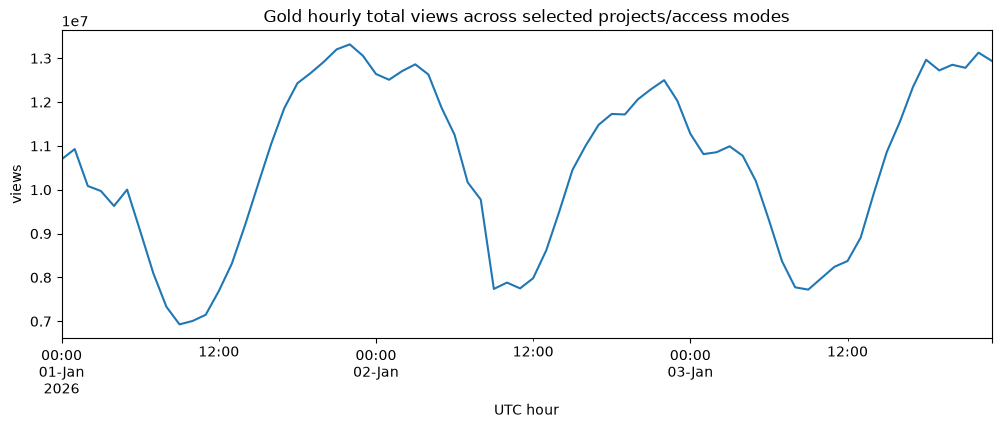

In [15]:
hourly_plot_df = hourly_df.copy()
hourly_plot_df["timestamp_utc"] = pd.to_datetime(hourly_plot_df["date"]) + pd.to_timedelta(
    hourly_plot_df["hour"], unit="h"
)

hourly_total_trend = (
    hourly_plot_df.groupby("timestamp_utc", as_index=False)["total_views"]
    .sum()
    .sort_values("timestamp_utc")
)

ax = hourly_total_trend.plot(
    x="timestamp_utc",
    y="total_views",
    figsize=(12, 4),
    title="Gold hourly total views across selected projects/access modes",
    legend=False,
)
ax.set_xlabel("UTC hour")
ax.set_ylabel("views")


## Optional Silver-to-Gold Reconciliation


In [16]:
if not RUN_SILVER_RECONCILIATION:
    print(
        "Skipped Silver scan. Set RUN_SILVER_RECONCILIATION = True in the setup cell "
        "to recompute hourly aggregates from Silver and compare them with Gold."
    )
elif not SILVER_DIR.exists():
    raise FileNotFoundError(f"Silver directory is missing: {SILVER_DIR}")
else:
    import duckdb

    silver_glob = (SILVER_DIR / "**" / "*.parquet").resolve().as_posix().replace("'", "''")
    con = duckdb.connect()
    silver_hourly = con.execute(
        f'''
        select
            cast(date as varchar) as date,
            cast(hour as smallint) as hour,
            project,
            access_mode,
            count(*) as page_rows_from_silver,
            cast(sum(view_count) as bigint) as total_views_from_silver,
            cast(sum(response_size) as bigint) as total_response_size_from_silver,
            max(view_count) as max_page_views_from_silver
        from read_parquet('{silver_glob}', hive_partitioning=true)
        group by 1, 2, 3, 4
        order by 1, 2, 3, 4
        '''
    ).fetchdf()

    silver_hourly = normalize_date_column(silver_hourly)
    silver_compare = hourly_df.merge(silver_hourly, on=hourly_key, how="outer", indicator=True)
    for metric in ["page_rows", "total_views", "total_response_size", "max_page_views"]:
        silver_compare[f"{metric}_delta"] = (
            silver_compare[metric] - silver_compare[f"{metric}_from_silver"]
        )

    silver_delta_columns = [column for column in silver_compare.columns if column.endswith("_delta")]
    silver_failures = silver_compare.loc[
        (silver_compare["_merge"] != "both")
        | silver_compare[silver_delta_columns].ne(0).any(axis=1)
    ]
    display(
        pd.DataFrame(
            [
                {"metric": "compared_hourly_keys", "value": len(silver_compare)},
                {"metric": "failed_hourly_keys", "value": len(silver_failures)},
                {"metric": "max_abs_total_views_delta", "value": silver_compare["total_views_delta"].abs().max()},
            ]
        )
    )
    display(silver_failures.head(25))


Skipped Silver scan. Set RUN_SILVER_RECONCILIATION = True in the setup cell to recompute hourly aggregates from Silver and compare them with Gold.


## Readiness Checklist


In [17]:
readiness_checks = {
    "manifest row counts match parquet rows": bool(contract_df["row_count_matches_manifest"].all()),
    "required schema columns present": bool(schema_check_df["required_columns_present"].all()),
    "table grains are unique": bool(grain_summary_df["passed"].all()),
    "observed coverage matches hourly row count": len(hourly_df) == expected_hourly_rows,
    "observed coverage matches daily row count": len(daily_df) == expected_daily_rows,
    "hourly metrics reconcile to daily metrics": reconciliation_failures.empty,
    "top page rank rules pass": invalid_rank_groups.empty and rank_order_violations.empty,
    "gold footprint remains below 10 GB cap": gold_total_bytes < DATA_BUDGET_BYTES,
    "total local data footprint remains below 10 GB cap": data_total_bytes < DATA_BUDGET_BYTES,
}

readiness_df = display_checklist(readiness_checks)
readiness_df


,check,passed,status
0,manifest row counts match parquet rows,True,PASS
1,required schema columns present,True,PASS
2,table grains are unique,True,PASS
3,observed coverage matches hourly row count,True,PASS
4,observed coverage matches daily row count,True,PASS
5,hourly metrics reconcile to daily metrics,True,PASS
6,top page rank rules pass,True,PASS
7,gold footprint remains below 10 GB cap,True,PASS
8,total local data footprint remains below 10 GB...,True,PASS


In [18]:
if not readiness_df["passed"].all():
    failed = readiness_df.loc[~readiness_df["passed"], "check"].tolist()
    raise AssertionError(f"Gold readiness checks failed: {failed}")

print("Gold inspection checks passed for the default read-only checks.")


Gold inspection checks passed for the default read-only checks.
